# 03. Analysis RQ1: Trend & Geopolitics (趋势与地缘政治)

**Research Question:** How have movie genres and production powerhouses shifted over the last 20 years?
**核心问题:** 过去20年间，电影类型的流行趋势和制片国家的版图发生了怎样的地缘与时间转移？

**Steps:**
1. Load Data & Preprocessing (加载数据与预处理)
2. Genre Evolution Analysis (电影类型演变分析)
3. Production Country Analysis (制片国家分析)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set(style="whitegrid")

# Load Processed Data
PROCESSED_DATA_PATH = '../data/processed/clean_tmdb_movies.csv'
df = pd.read_csv(PROCESSED_DATA_PATH)

# Parse list columns (they load as strings from CSV)
list_cols = ['genres', 'production_countries']
for col in list_cols:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

print(f"Data Loaded: {df.shape}")
display(df.head(2))

Data Loaded: (5698, 27)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,release_year,release_month,roi
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"[Action, Science Fiction, Adventure]","['Legendary Pictures', 'Syncopy', 'Warner Bros...","[United Kingdom, United States of America]","['English', 'French', 'Japanese', 'Swahili']","rescue, mission, dream, airplane, paris, franc...",2010.0,7.0,4.159580
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"[Adventure, Drama, Science Fiction]","['Legendary Pictures', 'Syncopy', 'Lynda Obst ...","[United Kingdom, United States of America]",['English'],"rescue, future, spacecraft, race against time,...",2014.0,11.0,3.252904


## 2. Genre Evolution (电影类型演变)
We will analyze how the popularity of different genres has changed over the years (2004-2023).

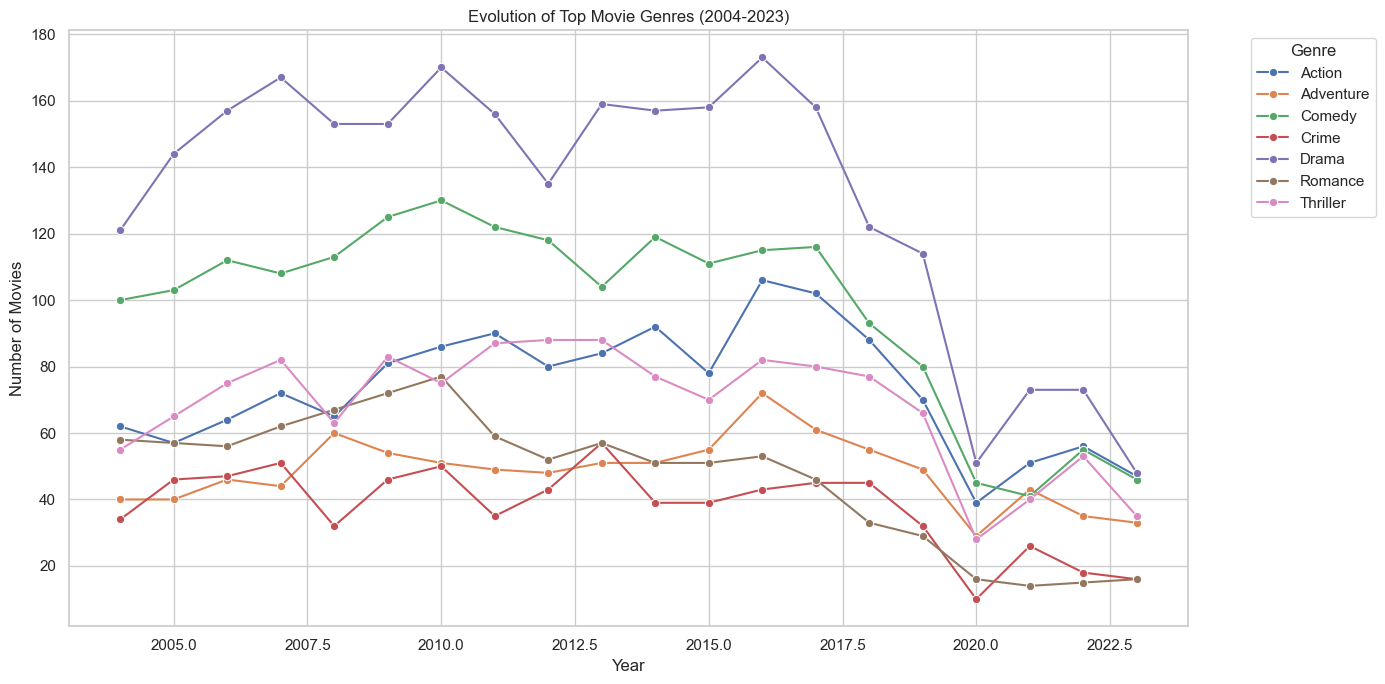

In [2]:
# Explode genres so each genre gets its own row
df_genres = df.explode('genres')

# Count movies per genre per year
genre_trends = df_genres.groupby(['release_year', 'genres']).size().reset_index(name='count')

# Filter for top 7 genres for cleaner visualization
top_genres = df_genres['genres'].value_counts().head(7).index.tolist()
genre_trends_top = genre_trends[genre_trends['genres'].isin(top_genres)]

# Pivot for plotting
genre_pivot = genre_trends_top.pivot(index='release_year', columns='genres', values='count').fillna(0)

# Plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=genre_trends_top, x='release_year', y='count', hue='genres', marker='o')
plt.title('Evolution of Top Movie Genres (2004-2023)')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Production Powerhouses (制片国家版图)
Which countries have been dominating the movie industry? Has there been a shift?

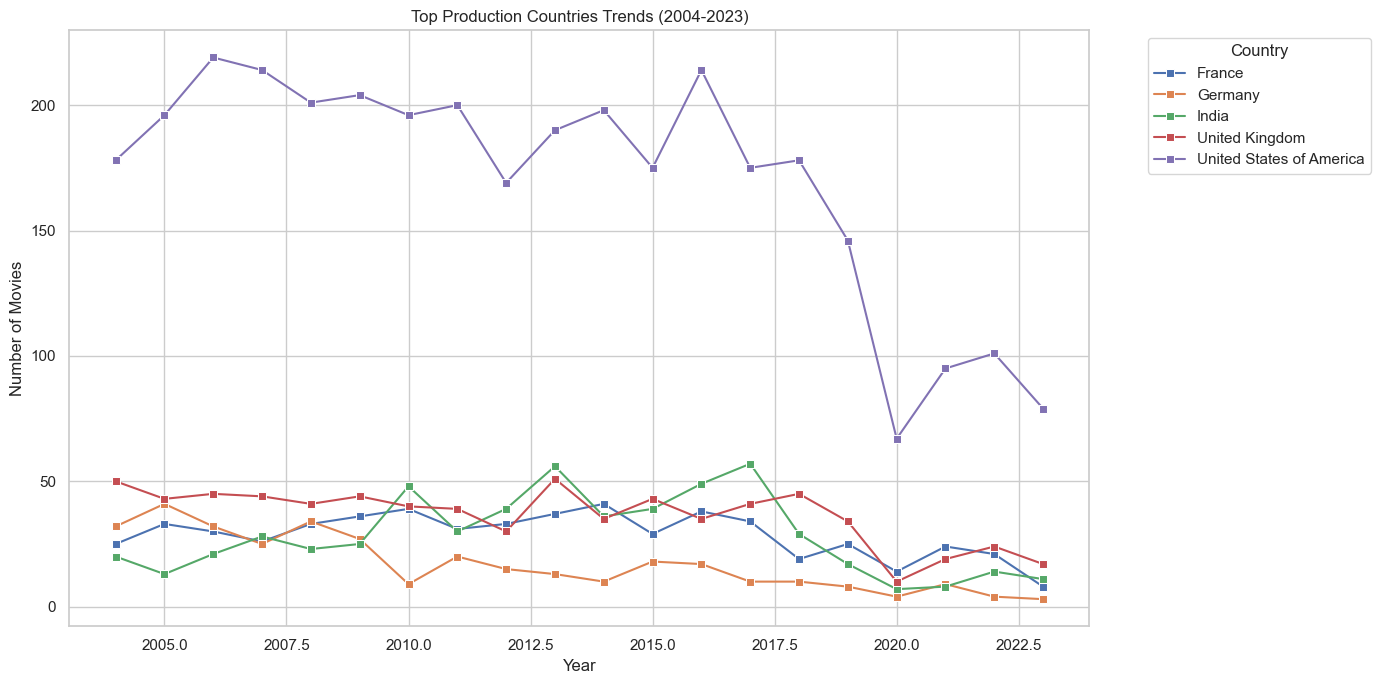

In [3]:
# Explode countries
df_countries = df.explode('production_countries')

# Count movies per country per year
country_trends = df_countries.groupby(['release_year', 'production_countries']).size().reset_index(name='count')

# Filter for top 5 countries (excluding USA usually dominates, let's see)
top_countries = df_countries['production_countries'].value_counts().head(5).index.tolist()
country_trends_top = country_trends[country_trends['production_countries'].isin(top_countries)]

# Plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=country_trends_top, x='release_year', y='count', hue='production_countries', marker='s')
plt.title('Top Production Countries Trends (2004-2023)')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()